# Data Preparation


PHASE 1 : CHARGEMENT

In [62]:
# Import libraries
import pandas as pd
from sklearn.feature_selection import SelectFromModel
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn import tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import SelectKBest, mutual_info_classif, chi2, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score , confusion_matrix, precision_score, recall_score, classification_report
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV
from sklearn.tree import export_graphviz
import graphviz
from sklearn.model_selection import LeaveOneOut

In [63]:
#Chargement des données

columns = [
    "SampleCodeNumber",
    "ClumpThickness",
    "UniformityCellSize",
    "UniformityCellShape",
    "MarginalAdhesion",
    "SingleEpithelialCellSize",
    "BareNuclei",
    "BlandChromatin",
    "NormalNucleoli",
    "Mitoses",
    "class"
]

data=pd.read_csv("breast-cancer-wisconsin.data",names=columns)
data.head()

,SampleCodeNumber,ClumpThickness,UniformityCellSize,UniformityCellShape,MarginalAdhesion,SingleEpithelialCellSize,BareNuclei,BlandChromatin,NormalNucleoli,Mitoses,class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [64]:
data.describe() # afficher les statistique sur la dataset

,SampleCodeNumber,ClumpThickness,UniformityCellSize,UniformityCellShape,MarginalAdhesion,SingleEpithelialCellSize,BlandChromatin,NormalNucleoli,Mitoses,class
count,6.990000e+02,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000
mean,1.071704e+06,4.417740,3.134478,3.207439,2.806867,3.216023,3.437768,2.866953,1.589413,2.689557
std,6.170957e+05,2.815741,3.051459,2.971913,2.855379,2.214300,2.438364,3.053634,1.715078,0.951273
min,6.163400e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,8.706885e+05,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,2.000000
50%,1.171710e+06,4.000000,1.000000,1.000000,1.000000,2.000000,3.000000,1.000000,1.000000,2.000000
75%,1.238298e+06,6.000000,5.000000,5.000000,4.000000,4.000000,5.000000,4.000000,1.000000,4.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


In [65]:
print(data.head())

   SampleCodeNumber  ClumpThickness  UniformityCellSize  UniformityCellShape  \
0           1000025               5                   1                    1   
1           1002945               5                   4                    4   
2           1015425               3                   1                    1   
3           1016277               6                   8                    8   
4           1017023               4                   1                    1   

   MarginalAdhesion  SingleEpithelialCellSize BareNuclei  BlandChromatin  \
0                 1                         2          1               3   
1                 5                         7         10               3   
2                 1                         2          2               3   
3                 1                         3          4               3   
4                 3                         2          1               3   

   NormalNucleoli  Mitoses  class  
0               1        1

In [66]:
def show_num_inst(data):
  # Compter le nombre d'instances pour chaque classe
  class_counts = data['class'].value_counts()

  # Définir les étiquettes et les valeurs pour le graph
  labels = class_counts.index
  values = class_counts.values

  # Configurer et afficher le graph
  plt.bar(labels, values)
  plt.xlabel('Class')
  plt.ylabel('Count')
  plt.title('Number of Instances per Class')
  plt.show()

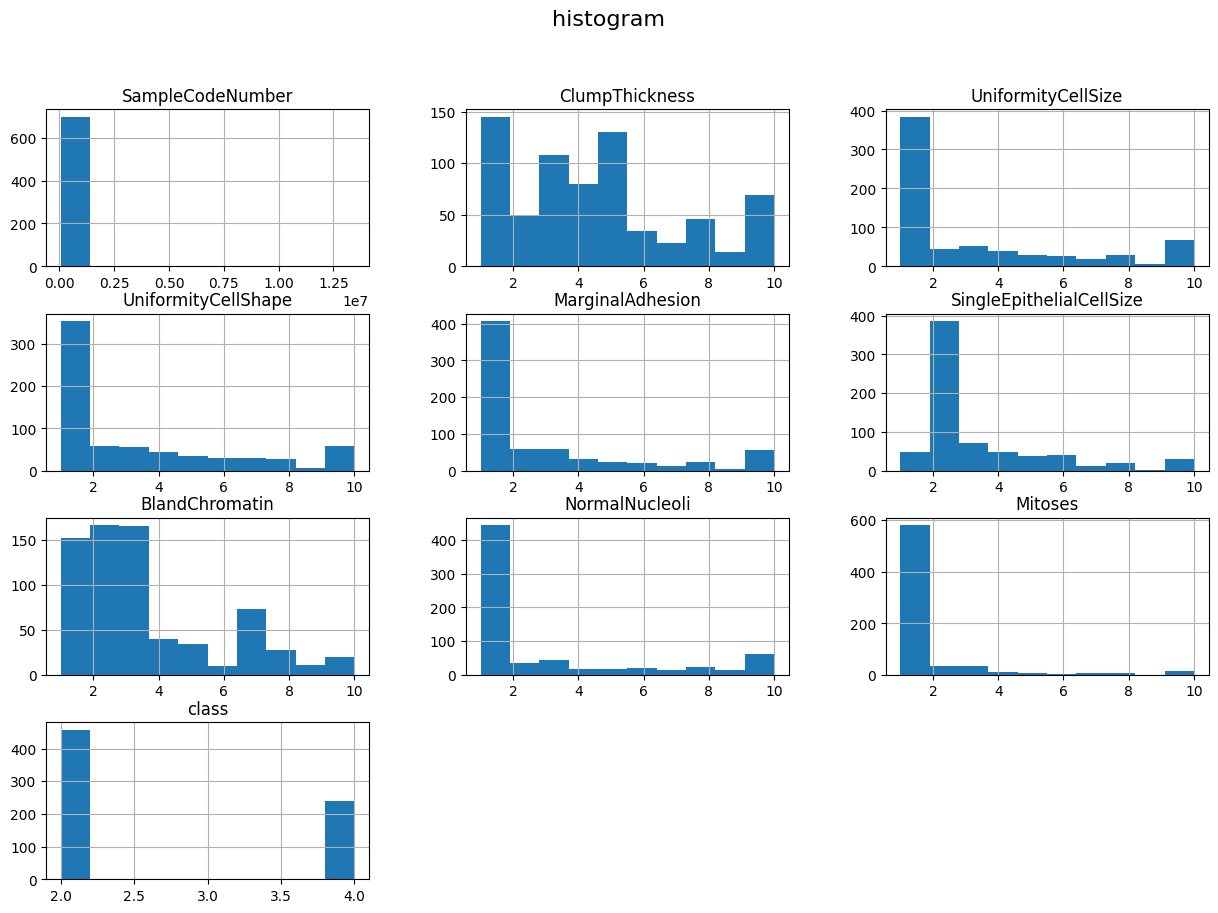

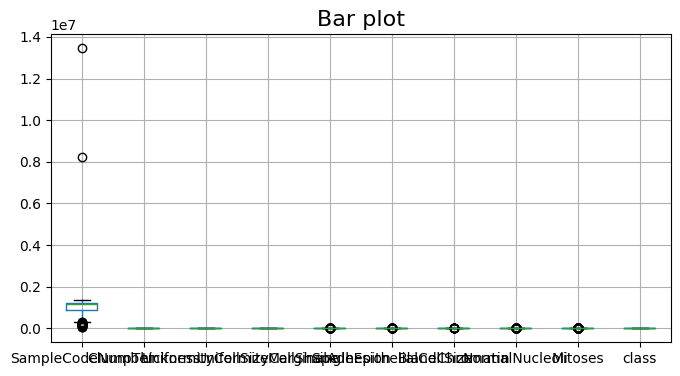

In [67]:
#histogramms
data.hist(figsize=(15,10))
plt.suptitle("histogram", fontsize=16)
plt.show()
#boxplot
data.boxplot(figsize=(8,4))
plt.title("Bar plot", fontsize=16)
plt.show()

PHASE 2 : NETTOYAGE

In [68]:
# 1. Supprimer colonne ID
data.drop("SampleCodeNumber", axis=1, inplace=True)

In [69]:

# 2. Remplacer "?" par NaN
data.replace("?", np.nan, inplace=True)


In [70]:
# 3. Convertir toutes les colonnes en numérique (important !)
for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

In [71]:
# 4. Supprimer les doublons
data.drop_duplicates(inplace=True)

In [72]:

# 5. Encoder la cible
data["class"] = data["class"].map({2: 0, 4: 1})

PHASE 3 : SPLIT

In [73]:
# 6. Séparer X et y
X = data.drop('class', axis=1)
y = data['class']

In [74]:
# 7. Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

PHASE 4 : PREPROCESSING

In [75]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
# 8. Imputation (FIT sur train, TRANSFORM sur test)
imputer = SimpleImputer(strategy="median")
X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

In [76]:
# 9. Normalisation (FIT sur train, TRANSFORM sur test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ARBRE DE DÉCISION

In [77]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import tree
# Feature names
feature_names = [
    'ClumpThickness', 'UniformityCellSize', 'UniformityCellShape',
    'MarginalAdhesion', 'SingleEpithelialCellSize', 'BareNuclei',
    'BlandChromatin', 'NormalNucleoli', 'Mitoses'
]

ÉTAPE 1 : TROUVER LE MEILLEUR ccp_alpha (PRUNING)

In [78]:
# Arbre complet pour extraire les alphas
clf_full = DecisionTreeClassifier(random_state=42)
path = clf_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]  # Enlever le dernier (arbre trivial)

In [79]:
# Tester chaque alpha
clfs_pruned = []
train_scores = []
test_scores = []

for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    clf.fit(X_train, y_train)
    clfs_pruned.append(clf)
    train_scores.append(clf.score(X_train, y_train))
    test_scores.append(clf.score(X_test, y_test))

In [80]:
# Trouver le meilleur alpha (meilleure accuracy sur test)
best_idx = test_scores.index(max(test_scores))
best_alpha = ccp_alphas[best_idx]
best_clf_pruned = clfs_pruned[best_idx]

print(f"\n✅ Meilleur ccp_alpha : {best_alpha:.6f}")
print(f"✅ Accuracy sur train : {train_scores[best_idx]:.4f}")
print(f"✅ Accuracy sur test  : {test_scores[best_idx]:.4f}")


✅ Meilleur ccp_alpha : 0.002703
✅ Accuracy sur train : 0.9838
✅ Accuracy sur test  : 0.9355


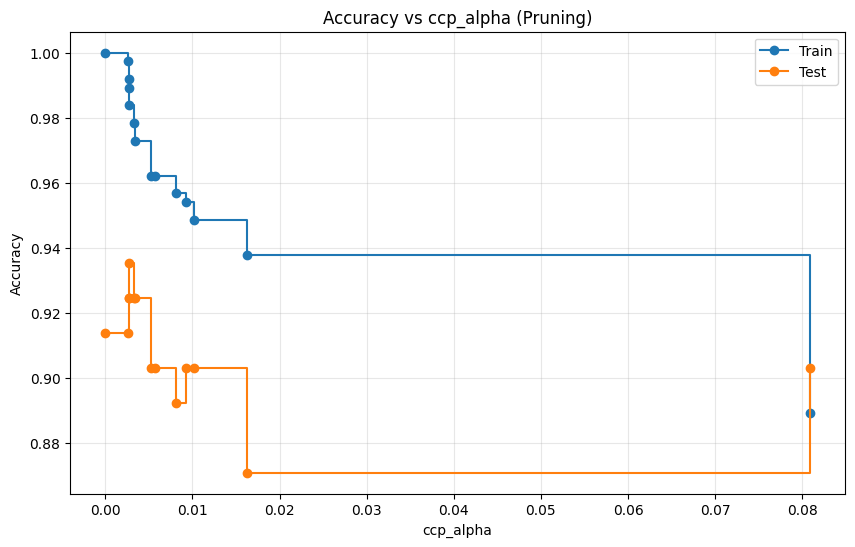

In [81]:
# Visualisation de l'évolution des scores
plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas, train_scores, marker='o', label='Train', drawstyle="steps-post")
plt.plot(ccp_alphas, test_scores, marker='o', label='Test', drawstyle="steps-post")
plt.xlabel('ccp_alpha')
plt.ylabel('Accuracy')
plt.title('Accuracy vs ccp_alpha (Pruning)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

ÉTAPE 2 : ENTRAÎNER LE MODÈLE FINAL AVEC MEILLEUR ALPHA

In [82]:
print("\n" + "=" * 60)
print("MODÈLE FINAL (avec meilleur alpha)")
print("=" * 60)

# Modèle final avec meilleur alpha
clf_final = DecisionTreeClassifier(
    ccp_alpha=best_alpha,
    random_state=42
)
clf_final.fit(X_train, y_train)


MODÈLE FINAL (avec meilleur alpha)


DecisionTreeClassifier(ccp_alpha=np.float64(0.002702702702702703),
                       random_state=42)

In [83]:
# Prédictions
y_pred_train = clf_final.predict(X_train)
y_pred_test = clf_final.predict(X_test)

In [84]:
# Métriques
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"\n📊 Accuracy Train : {acc_train:.4f}")
print(f"📊 Accuracy Test  : {acc_test:.4f}")
print(f"📊 Différence     : {abs(acc_train - acc_test):.4f} {'✅ Pas de surapprentissage' if abs(acc_train - acc_test) < 0.05 else '⚠️ Surapprentissage possible'}")


📊 Accuracy Train : 0.9838
📊 Accuracy Test  : 0.9355
📊 Différence     : 0.0483 ✅ Pas de surapprentissage


ÉTAPE 3 : RAPPORT DE CLASSIFICATION

In [85]:
print("\n📋 Rapport de classification (Test set) :")
print(classification_report(y_test, y_pred_test, target_names=['Bénin (0)', 'Malin (1)']))


📋 Rapport de classification (Test set) :
              precision    recall  f1-score   support

   Bénin (0)       0.95      0.91      0.93        45
   Malin (1)       0.92      0.96      0.94        48

    accuracy                           0.94        93
   macro avg       0.94      0.93      0.94        93
weighted avg       0.94      0.94      0.94        93



ÉTAPE 4 : MATRICE DE CONFUSION

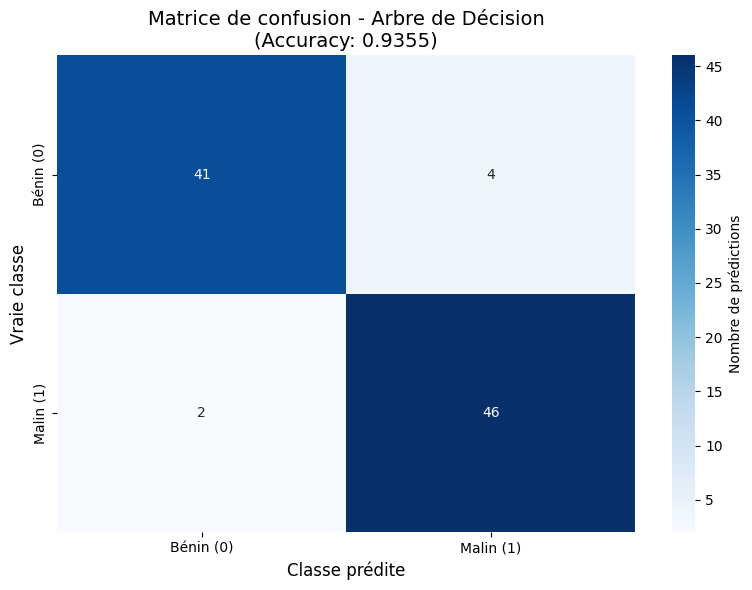

In [86]:
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bénin (0)', 'Malin (1)'],
            yticklabels=['Bénin (0)', 'Malin (1)'],
            cbar_kws={'label': 'Nombre de prédictions'})
plt.title(f'Matrice de confusion - Arbre de Décision\n(Accuracy: {acc_test:.4f})', fontsize=14)
plt.ylabel('Vraie classe', fontsize=12)
plt.xlabel('Classe prédite', fontsize=12)
plt.tight_layout()
plt.show()


ÉTAPE 5 : VISUALISATION DE L'ARBRE

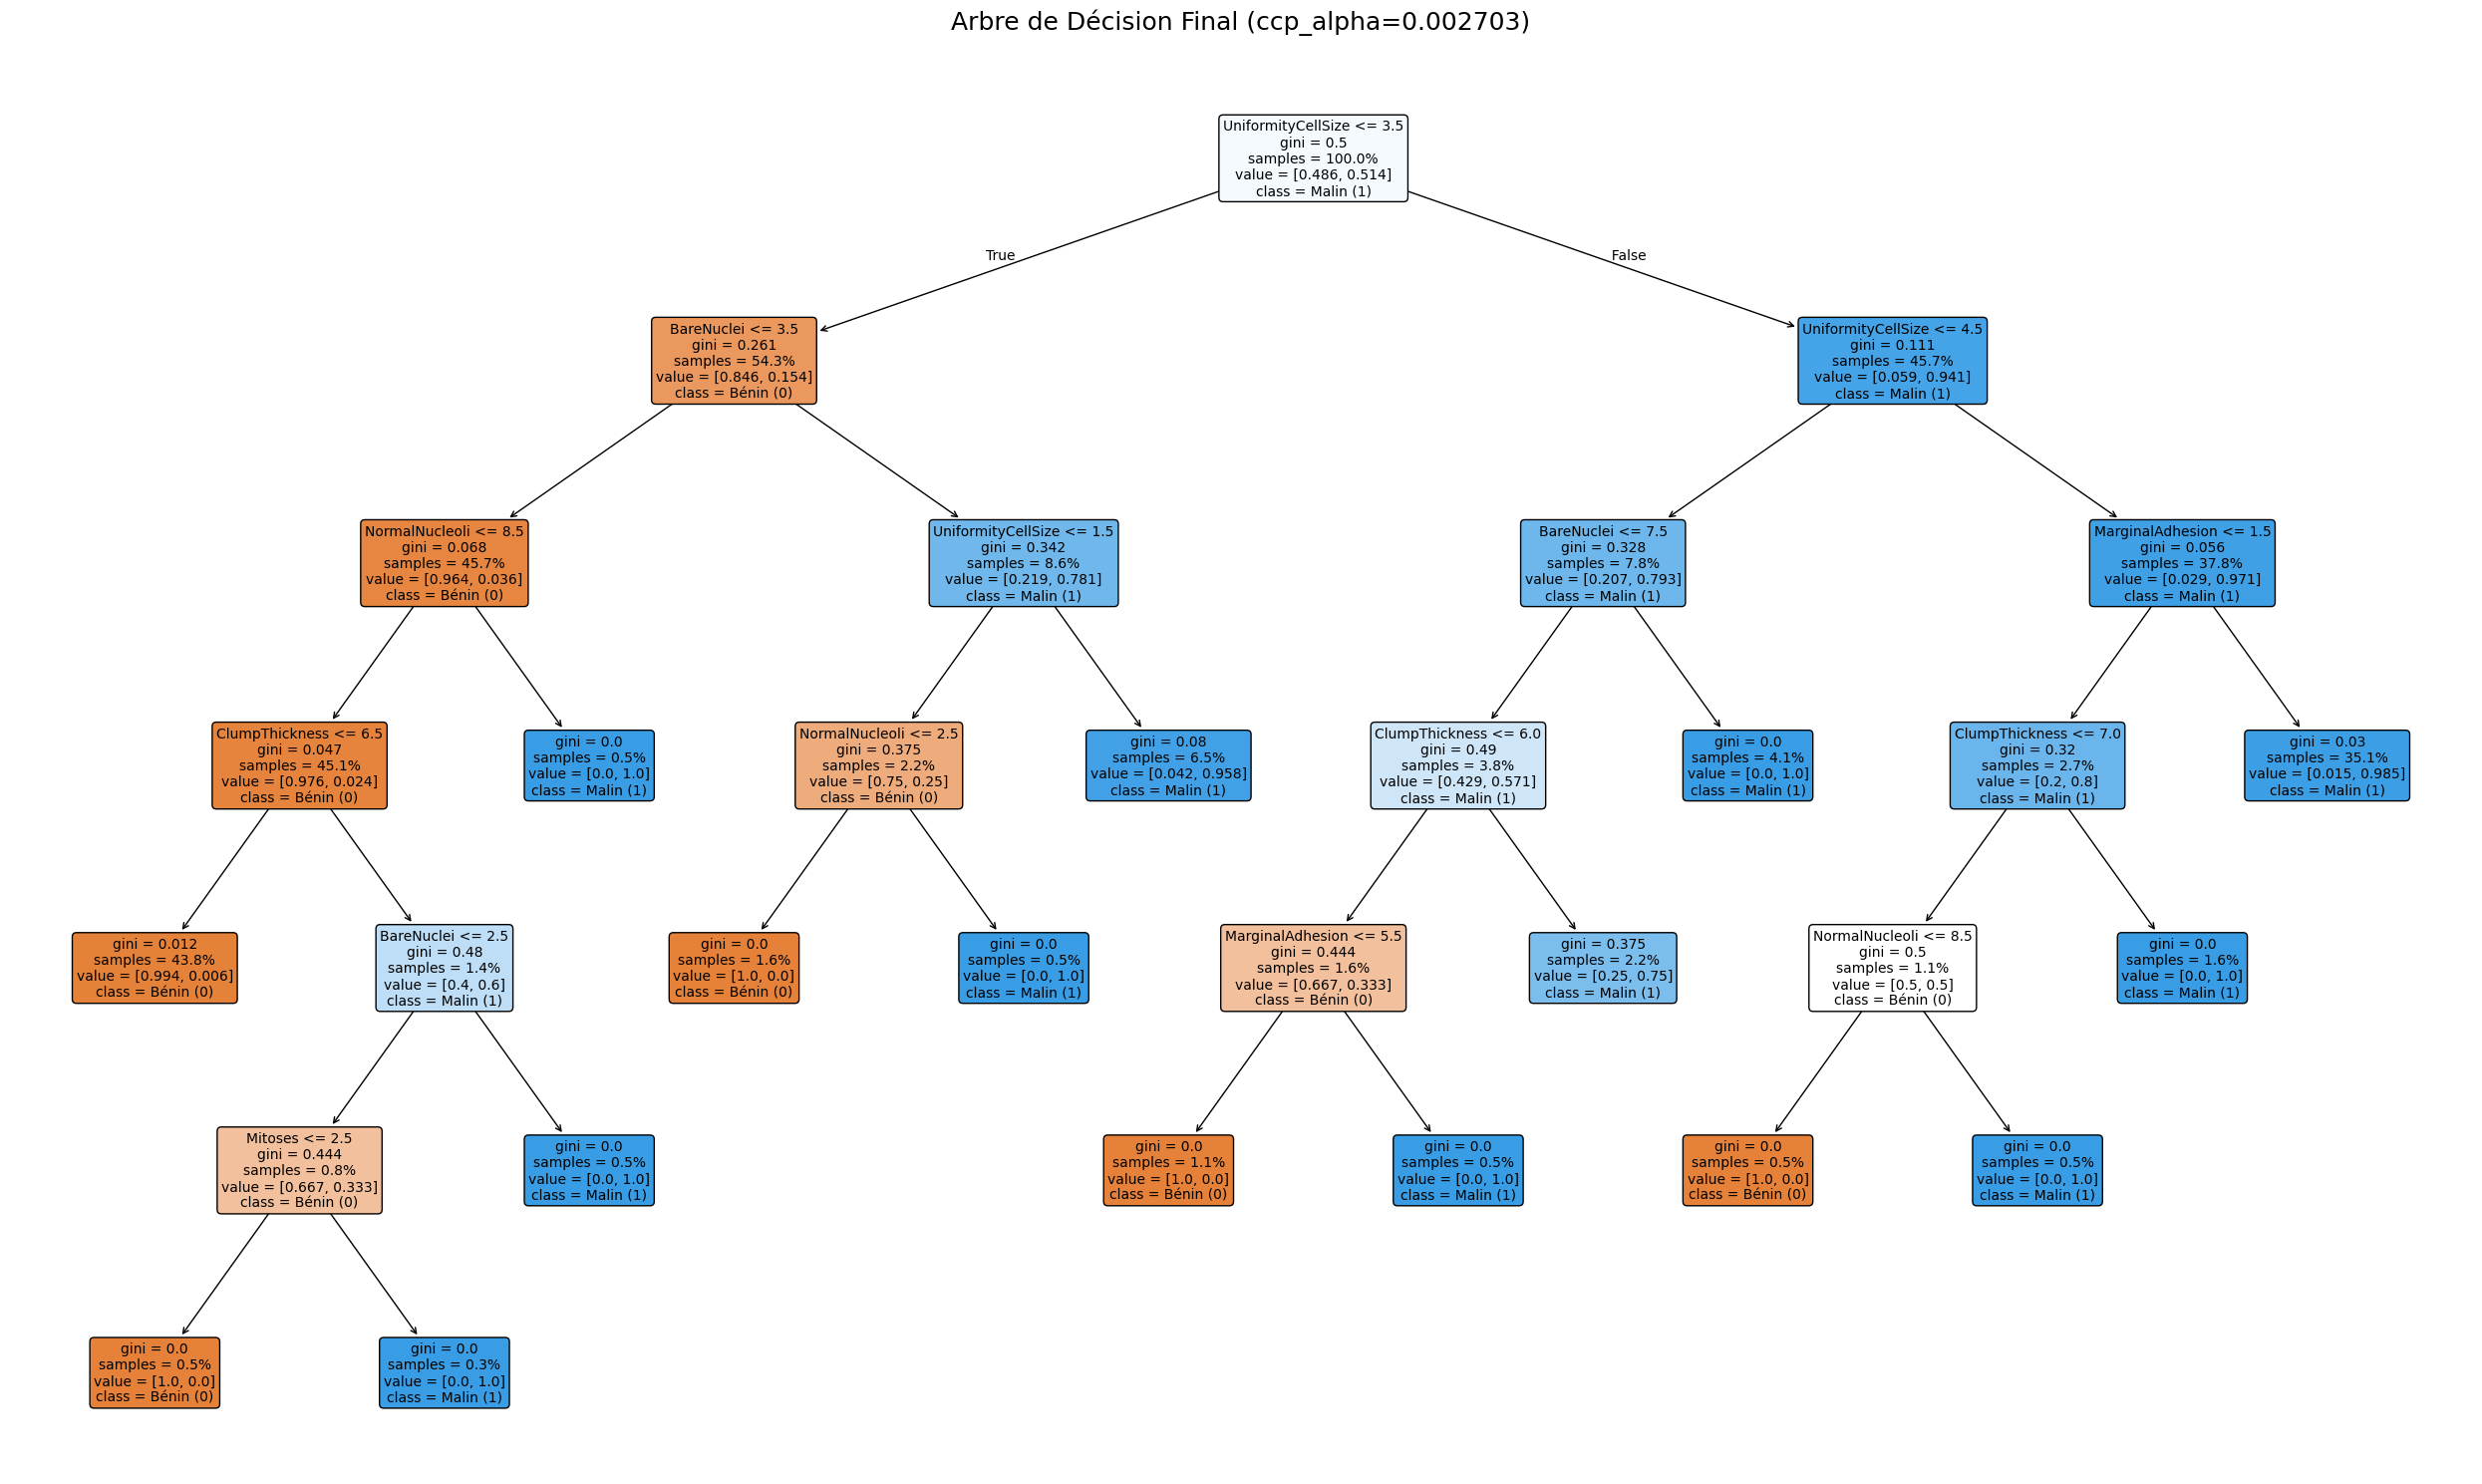

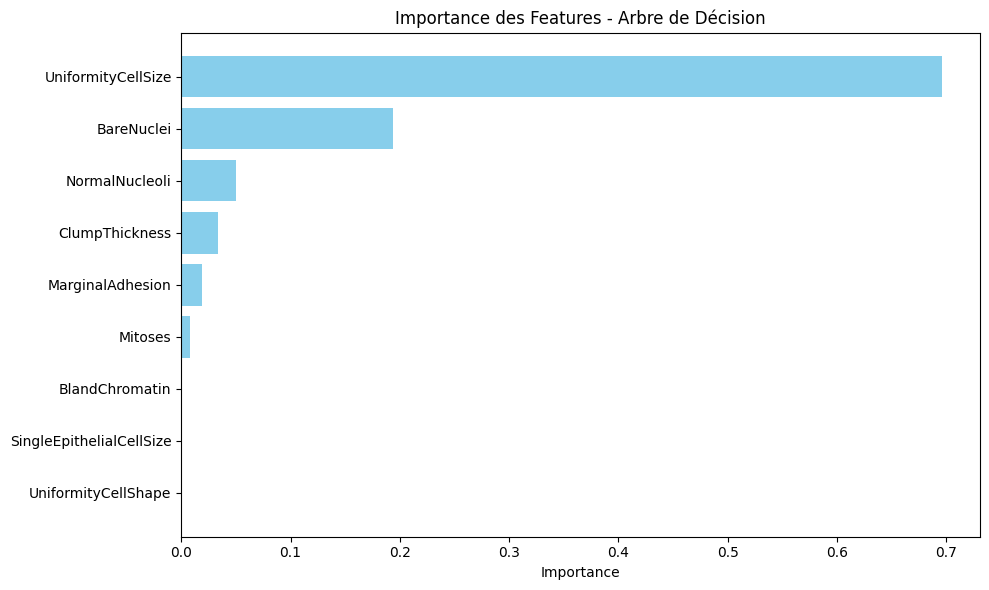

In [87]:
plt.figure(figsize=(25, 15))
tree.plot_tree(
    clf_final,
    feature_names=feature_names,
    class_names=['Bénin (0)', 'Malin (1)'],
    filled=True,
    rounded=True,
    fontsize=10,
    proportion=True,
    impurity=True
)
plt.title(f"Arbre de Décision Final (ccp_alpha={best_alpha:.6f})", fontsize=18, pad=20)
plt.tight_layout()
plt.show()

# ========== ÉTAPE 6 : IMPORTANCE DES FEATURES ==========
importances = clf_final.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], color='skyblue')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Importance')
plt.title('Importance des Features - Arbre de Décision')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



# K-NEAREST NEIGHBORS (KNN)

In [88]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



ÉTAPE 1 : TROUVER LE MEILLEUR K

In [89]:
k_values = range(1, 31)  # Tester de k=1 à k=30
train_scores = []
test_scores = []
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    # Score train
    train_scores.append(knn.score(X_train_scaled, y_train))

    # Score test
    test_scores.append(knn.score(X_test_scaled, y_test))

    # Score cross-validation (5-fold)
    cv_score = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(cv_score.mean())

In [90]:
# Trouver le meilleur k basé sur CV score
best_k_idx = cv_scores.index(max(cv_scores))
best_k = list(k_values)[best_k_idx]

print(f"\n✅ Meilleur k : {best_k}")
print(f"✅ CV Score (5-fold) : {cv_scores[best_k_idx]:.4f}")
print(f"✅ Test Score : {test_scores[best_k_idx]:.4f}")



✅ Meilleur k : 15
✅ CV Score (5-fold) : 0.9595
✅ Test Score : 0.9462


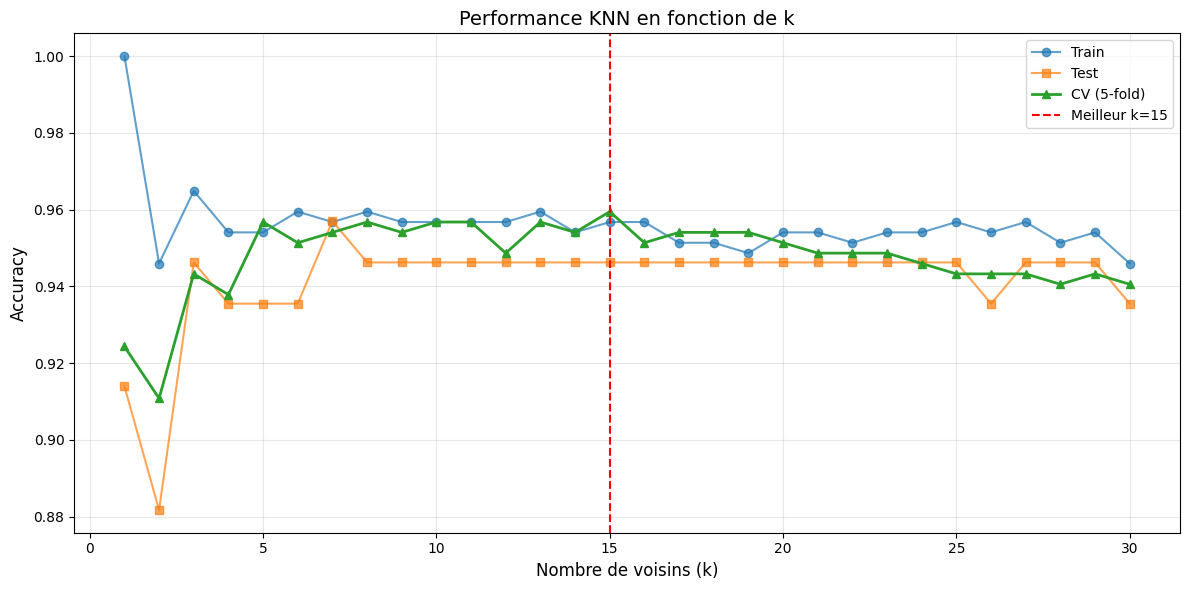

In [91]:
# Visualisation des scores
plt.figure(figsize=(12, 6))
plt.plot(k_values, train_scores, marker='o', label='Train', alpha=0.7)
plt.plot(k_values, test_scores, marker='s', label='Test', alpha=0.7)
plt.plot(k_values, cv_scores, marker='^', label='CV (5-fold)', linewidth=2)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Meilleur k={best_k}')
plt.xlabel('Nombre de voisins (k)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Performance KNN en fonction de k', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

ÉTAPE 2 : ENTRAÎNER LE MODÈLE FINAL

In [92]:
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=15)

In [93]:
# Prédictions
y_pred_train = knn_final.predict(X_train_scaled)
y_pred_test = knn_final.predict(X_test_scaled)

In [94]:
# Métriques
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"\n📊 Accuracy Train : {acc_train:.4f}")
print(f"📊 Accuracy Test  : {acc_test:.4f}")
print(f"📊 Différence     : {abs(acc_train - acc_test):.4f}")


📊 Accuracy Train : 0.9568
📊 Accuracy Test  : 0.9462
📊 Différence     : 0.0105


ÉTAPE 3 : RAPPORT DE CLASSIFICATION

In [95]:
print("\n📋 Rapport de classification (Test set) :")
print(classification_report(y_test, y_pred_test, target_names=['Bénin (0)', 'Malin (1)']))



📋 Rapport de classification (Test set) :
              precision    recall  f1-score   support

   Bénin (0)       0.95      0.93      0.94        45
   Malin (1)       0.94      0.96      0.95        48

    accuracy                           0.95        93
   macro avg       0.95      0.95      0.95        93
weighted avg       0.95      0.95      0.95        93



ÉTAPE 4 : MATRICE DE CONFUSION

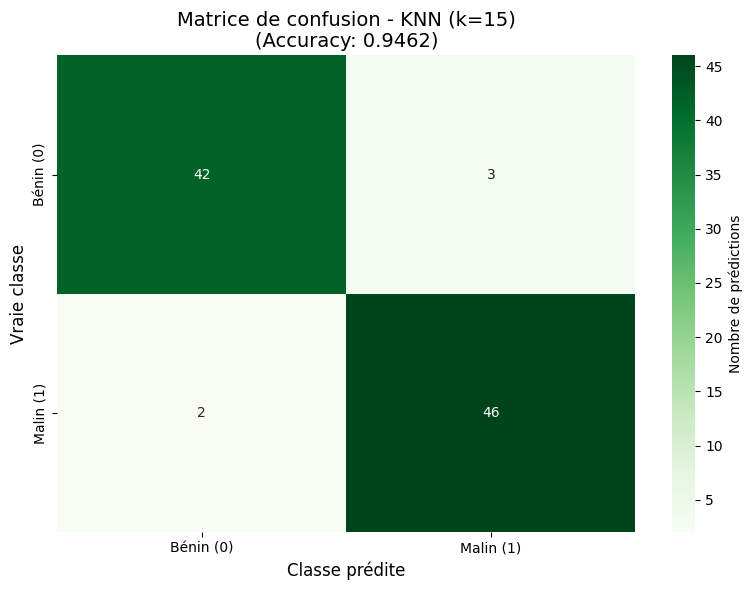

In [96]:
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Bénin (0)', 'Malin (1)'],
            yticklabels=['Bénin (0)', 'Malin (1)'],
            cbar_kws={'label': 'Nombre de prédictions'})
plt.title(f'Matrice de confusion - KNN (k={best_k})\n(Accuracy: {acc_test:.4f})', fontsize=14)
plt.ylabel('Vraie classe', fontsize=12)
plt.xlabel('Classe prédite', fontsize=12)
plt.tight_layout()
plt.show()


# RÉSEAUX DE NEURONES

ÉTAPE 1 : RECHERCHE DES MEILLEURS HYPERPARAMÈTRES

In [97]:
# Définir la grille de paramètres à tester
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],  # Architecture
    'activation': ['relu', 'tanh'],                               # Fonction d'activation
    'alpha': [0.0001, 0.001, 0.01],                              # Régularisation L2
    'learning_rate_init': [0.001, 0.01],                         # Taux d'apprentissage
    'max_iter': [500]                                            # Nombre d'itérations max
}


In [98]:
# Créer le modèle de base
mlp = MLPClassifier(random_state=42, early_stopping=True, validation_fraction=0.1)
# GridSearch avec cross-validation
grid_search = GridSearchCV(
    mlp,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

In [99]:
# Entraîner le GridSearch
grid_search.fit(X_train_scaled, y_train)


Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5,
             estimator=MLPClassifier(early_stopping=True, random_state=42),
             n_jobs=-1,
             param_grid={'activation': ['relu', 'tanh'],
                         'alpha': [0.0001, 0.001, 0.01],
                         'hidden_layer_sizes': [(50,), (100,), (50, 50),
                                                (100, 50)],
                         'learning_rate_init': [0.001, 0.01],
                         'max_iter': [500]},
             scoring='accuracy', verbose=1)

In [100]:
# Meilleurs paramètres
best_params = grid_search.best_params_
print(f"\n✅ Meilleurs paramètres trouvés :")
for param, value in best_params.items():
    print(f"   {param}: {value}")
print(f"\n✅ Meilleur CV Score : {grid_search.best_score_:.4f}")




✅ Meilleurs paramètres trouvés :
   activation: relu
   alpha: 0.0001
   hidden_layer_sizes: (50,)
   learning_rate_init: 0.01
   max_iter: 500

✅ Meilleur CV Score : 0.9432


ÉTAPE 2 : ENTRAÎNER LE MODÈLE FINAL

In [101]:
# Modèle final avec meilleurs paramètres
mlp_final = MLPClassifier(
    hidden_layer_sizes=best_params['hidden_layer_sizes'],
    activation=best_params['activation'],
    alpha=best_params['alpha'],
    learning_rate_init=best_params['learning_rate_init'],
    max_iter=best_params['max_iter'],
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    verbose=False
)

mlp_final.fit(X_train_scaled, y_train)

MLPClassifier(early_stopping=True, hidden_layer_sizes=(50,),
              learning_rate_init=0.01, max_iter=500, random_state=42)

In [102]:
# Prédictions
y_pred_train = mlp_final.predict(X_train_scaled)
y_pred_test = mlp_final.predict(X_test_scaled)

In [103]:
# Métriques
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"\n📊 Accuracy Train : {acc_train:.4f}")
print(f"📊 Accuracy Test  : {acc_test:.4f}")
print(f"📊 Différence     : {abs(acc_train - acc_test):.4f}")


📊 Accuracy Train : 0.9351
📊 Accuracy Test  : 0.9355
📊 Différence     : 0.0003


ÉTAPE 3 : RAPPORT DE CLASSIFICATION

In [104]:
print("\n📋 Rapport de classification (Test set) :")
print(classification_report(y_test, y_pred_test, target_names=['Bénin (0)', 'Malin (1)']))


📋 Rapport de classification (Test set) :
              precision    recall  f1-score   support

   Bénin (0)       0.93      0.93      0.93        45
   Malin (1)       0.94      0.94      0.94        48

    accuracy                           0.94        93
   macro avg       0.94      0.94      0.94        93
weighted avg       0.94      0.94      0.94        93



ÉTAPE 4 : MATRICE DE CONFUSION

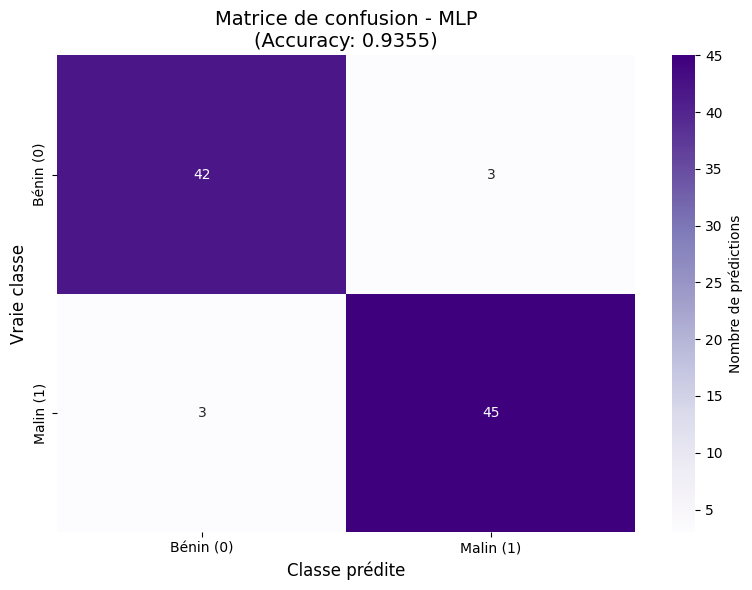

In [105]:
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Bénin (0)', 'Malin (1)'],
            yticklabels=['Bénin (0)', 'Malin (1)'],
            cbar_kws={'label': 'Nombre de prédictions'})
plt.title(f'Matrice de confusion - MLP\n(Accuracy: {acc_test:.4f})', fontsize=14)
plt.ylabel('Vraie classe', fontsize=12)
plt.xlabel('Classe prédite', fontsize=12)
plt.tight_layout()
plt.show()

ÉTAPE 5 : COURBE D'APPRENTISSAGE

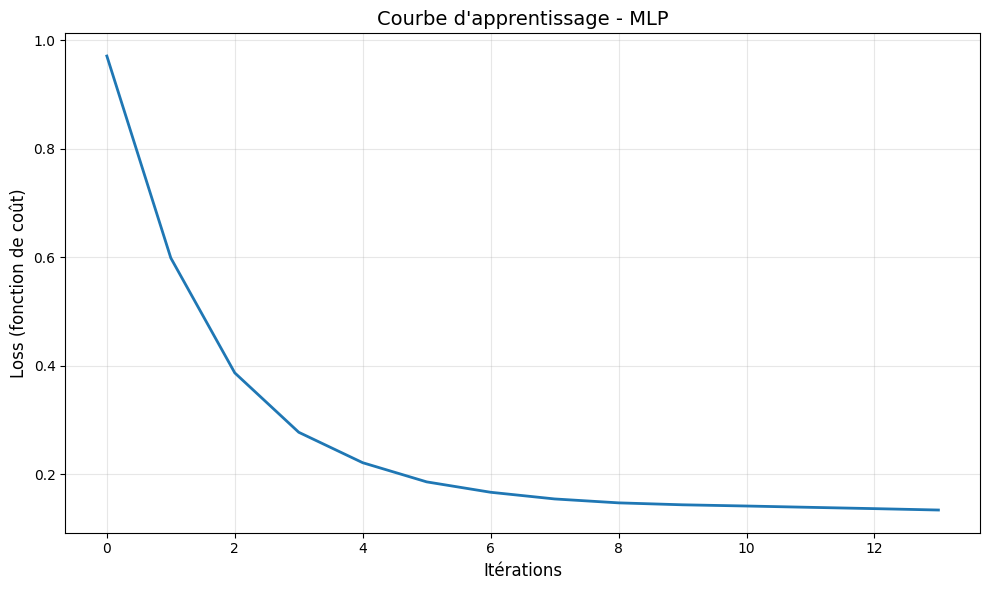

In [106]:
# Visualiser la convergence du modèle
plt.figure(figsize=(10, 6))
plt.plot(mlp_final.loss_curve_, linewidth=2)
plt.xlabel('Itérations', fontsize=12)
plt.ylabel('Loss (fonction de coût)', fontsize=12)
plt.title('Courbe d\'apprentissage - MLP', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# RANDOM FOREST


ÉTAPE 1 : RECHERCHE DES MEILLEURS HYPERPARAMÈTRES

In [107]:
# Grille de paramètres
param_grid = {
    'n_estimators': [100, 200],              # Réduit à 2 valeurs
    'max_depth': [10, 15, None],             # Réduit à 3 valeurs
    'min_samples_split': [2, 5],             # Réduit à 2 valeurs
    'max_features': ['sqrt']                 # Une seule valeur (meilleure pratique)
}


In [108]:
# Modèle de base
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# GridSearch avec MOINS de combinaisons
grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=3,              # ⚠️ Réduit à 3 folds (au lieu de 5)
    scoring='accuracy',
    n_jobs=-1,
    verbose=2          # Plus de détails
)

print("⏳ Entraînement du GridSearch en cours (cela peut prendre 1-2 minutes)...")
grid_search.fit(X_train, y_train)

⏳ Entraînement du GridSearch en cours (cela peut prendre 1-2 minutes)...
Fitting 3 folds for each of 12 candidates, totalling 36 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [10, 15, None], 'max_features': ['sqrt'],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy', verbose=2)

In [109]:
# Vérifier que best_params_ existe
if hasattr(grid_search, 'best_params_'):
    best_params = grid_search.best_params_
    print(f"\n✅ Meilleurs paramètres trouvés :")
    for param, value in best_params.items():
        print(f"   {param}: {value}")
    print(f"\n✅ Meilleur CV Score : {grid_search.best_score_:.4f}")
else:
    print("❌ Erreur : GridSearch n'a pas retourné de résultats")
    # Utiliser des valeurs par défaut
    best_params = {
        'n_estimators': 100,
        'max_depth': None,
        'min_samples_split': 2,
        'max_features': 'sqrt'
    }
    print("⚠️ Utilisation de paramètres par défaut")


✅ Meilleurs paramètres trouvés :
   max_depth: 10
   max_features: sqrt
   min_samples_split: 2
   n_estimators: 100

✅ Meilleur CV Score : 0.9514


ÉTAPE 2 : ENTRAÎNER LE MODÈLE FINAL

In [110]:
rf_final = RandomForestClassifier(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    max_features=best_params.get('max_features', 'sqrt'),  # Sécurité supplémentaire
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_jobs=-1, random_state=42)

ÉTAPE 4 : MATRICE DE CONFUSION

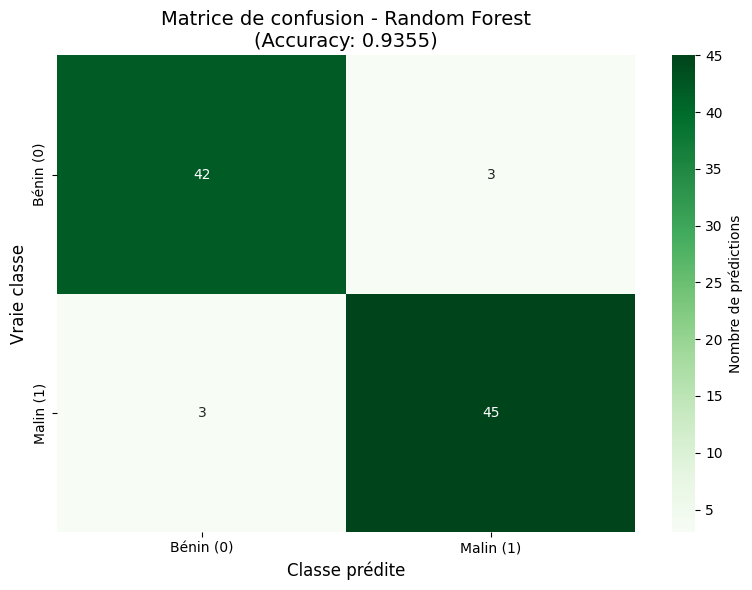

In [111]:
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Bénin (0)', 'Malin (1)'],
            yticklabels=['Bénin (0)', 'Malin (1)'],
            cbar_kws={'label': 'Nombre de prédictions'})
plt.title(f'Matrice de confusion - Random Forest\n(Accuracy: {acc_test:.4f})', fontsize=14)
plt.ylabel('Vraie classe', fontsize=12)
plt.xlabel('Classe prédite', fontsize=12)
plt.tight_layout()
plt.show()


ÉTAPE 5 : IMPORTANCE DES FEATURES

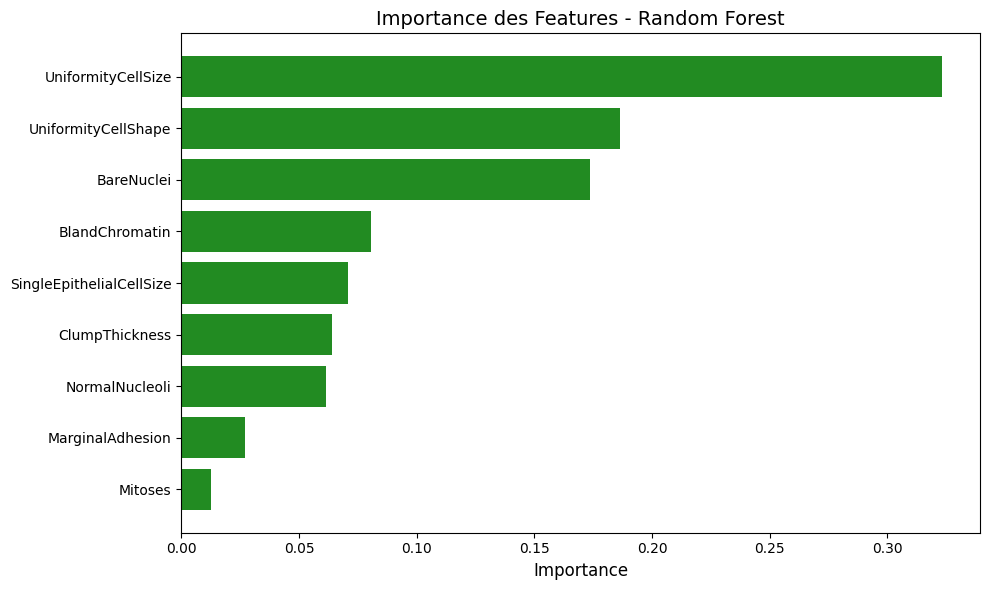

In [112]:
feature_names = X_train.columns.tolist()
importances = rf_final.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], color='forestgreen')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Importance', fontsize=12)
plt.title('Importance des Features - Random Forest', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#ADABOOST

In [113]:
from sklearn.ensemble import AdaBoostClassifier

ÉTAPE 1 : TESTER PLUSIEURS CONFIGURATIONS MANUELLEMENT

In [114]:
from sklearn.ensemble import AdaBoostClassifier

In [115]:
configs = [
    {'n_estimators': 50, 'learning_rate': 1.0, 'max_depth': 1},
    {'n_estimators': 100, 'learning_rate': 1.0, 'max_depth': 1},
    {'n_estimators': 50, 'learning_rate': 0.5, 'max_depth': 1},
    {'n_estimators': 100, 'learning_rate': 0.5, 'max_depth': 2},
    {'n_estimators': 50, 'learning_rate': 1.0, 'max_depth': 2},
]

best_score = 0
best_config = None

for i, config in enumerate(configs):
    # ⚠️ CORRECTION : Utiliser 'estimator' au lieu de 'base_estimator'
    base_tree = DecisionTreeClassifier(
        max_depth=config['max_depth'],
        random_state=42
    )

    ada_temp = AdaBoostClassifier(
        estimator=base_tree,  # ✅ 'estimator' (nouveau nom)
        n_estimators=config['n_estimators'],
        learning_rate=config['learning_rate'],
        random_state=42,
        algorithm='SAMME'
    )

    # Cross-validation
    cv_scores = cross_val_score(
    ada_temp,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)
    mean_score = cv_scores.mean()


    if mean_score > best_score:
        best_score = mean_score
        best_config = config

for param, value in best_config.items():
    print(f"   {param}: {value}")
print(f"✅ Meilleur CV Score : {best_score:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 

   n_estimators: 100
   learning_rate: 0.5
   max_depth: 2
✅ Meilleur CV Score : 0.9459


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


ÉTAPE 2 : ENTRAÎNER LE MODÈLE FINAL

In [116]:
base_tree_final = DecisionTreeClassifier(
    max_depth=best_config['max_depth'],
    random_state=42
)

ada_final = AdaBoostClassifier(
    estimator=base_tree_final,   # ✅ CORRECT
    n_estimators=best_config['n_estimators'],
    learning_rate=best_config['learning_rate'],
    random_state=42,
    algorithm='SAMME'
)

# IMPORTANT : utiliser les données normalisées
ada_final.fit(X_train, y_train)

# Prédictions
y_pred_train = ada_final.predict(X_train)
y_pred_test = ada_final.predict(X_test)

# Métriques
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"\n📊 Accuracy Train : {acc_train:.4f}")
print(f"📊 Accuracy Test  : {acc_test:.4f}")
print(f"📊 Différence     : {abs(acc_train - acc_test):.4f}")


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(



📊 Accuracy Train : 0.9946
📊 Accuracy Test  : 0.9355
📊 Différence     : 0.0591


ÉTAPE 3 : RAPPORT DE CLASSIFICATION

In [117]:
print("\n📋 Rapport de classification (Test set) :")
print(classification_report(y_test, y_pred_test, target_names=['Bénin (0)', 'Malin (1)']))


📋 Rapport de classification (Test set) :
              precision    recall  f1-score   support

   Bénin (0)       0.93      0.93      0.93        45
   Malin (1)       0.94      0.94      0.94        48

    accuracy                           0.94        93
   macro avg       0.94      0.94      0.94        93
weighted avg       0.94      0.94      0.94        93



ÉTAPE 4 : MATRICE DE CONFUSION

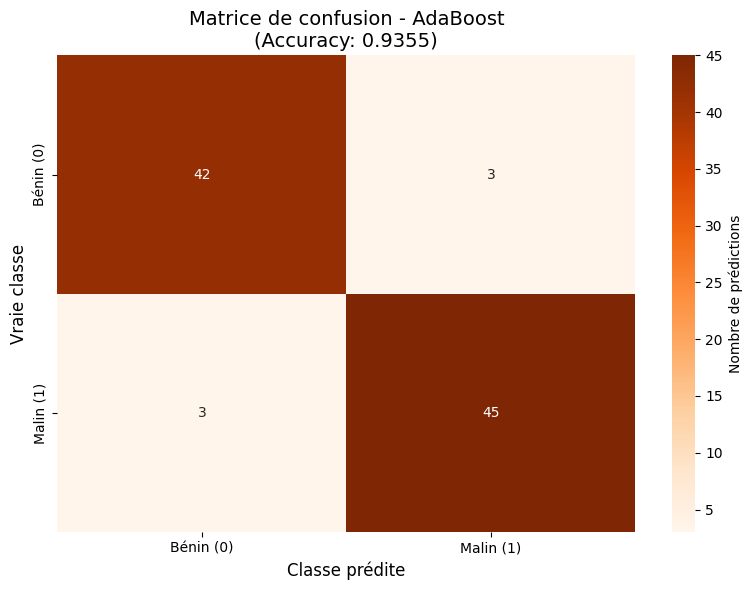

In [118]:
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Bénin (0)', 'Malin (1)'],
            yticklabels=['Bénin (0)', 'Malin (1)'],
            cbar_kws={'label': 'Nombre de prédictions'})
plt.title(f'Matrice de confusion - AdaBoost\n(Accuracy: {acc_test:.4f})', fontsize=14)
plt.ylabel('Vraie classe', fontsize=12)
plt.xlabel('Classe prédite', fontsize=12)
plt.tight_layout()
plt.show()

ÉTAPE 5 : IMPORTANCE DES FEATURES

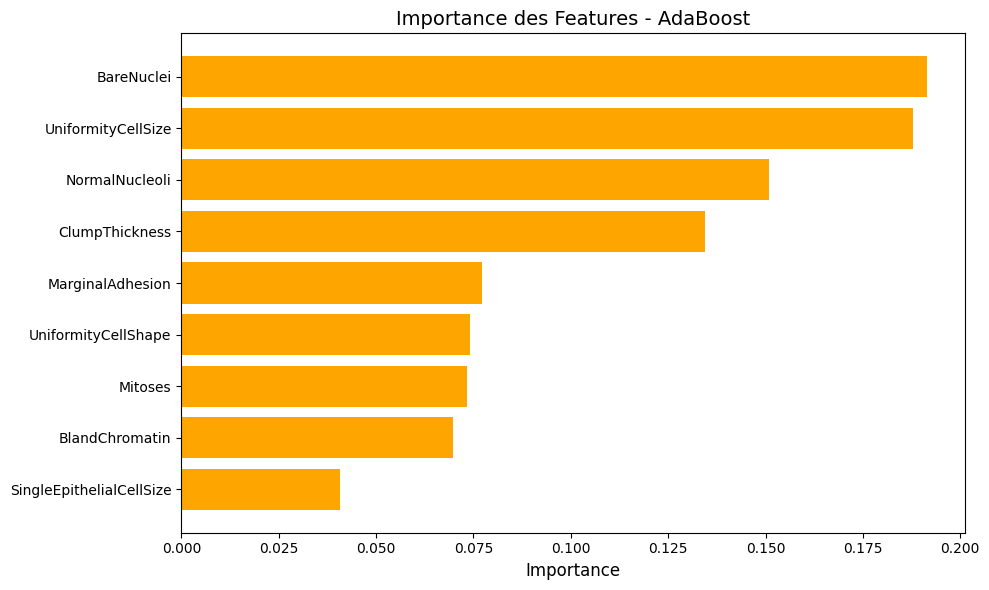

In [119]:
feature_names = X_train.columns.tolist()
importances = ada_final.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], color='orange')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Importance', fontsize=12)
plt.title('Importance des Features - AdaBoost', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

ÉTAPE 6 : ÉVOLUTION DE L'ERREUR

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


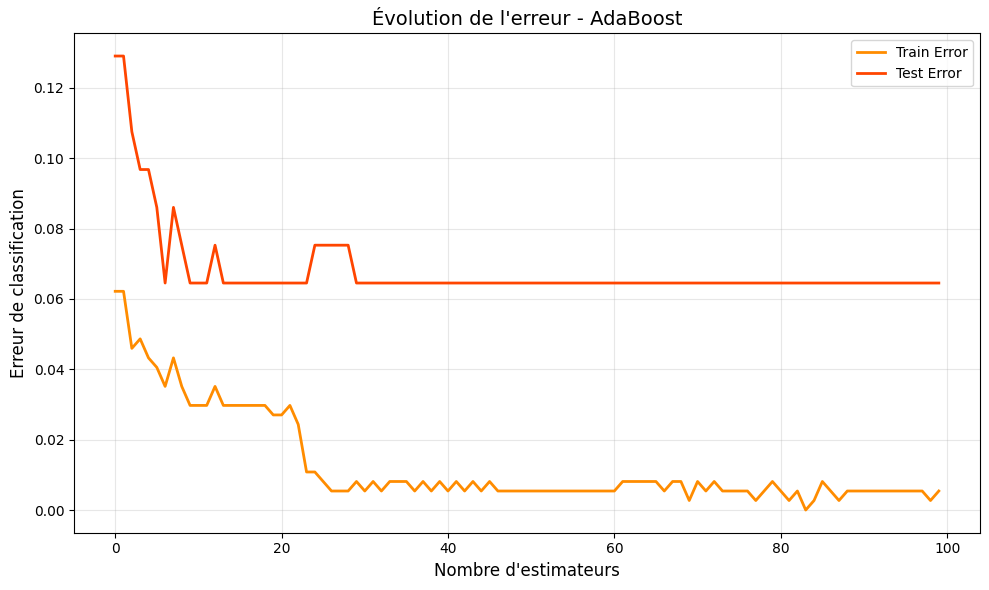

In [120]:
train_errors = []
test_errors = []

for y_pred in ada_final.staged_predict(X_train):
    train_errors.append(1 - accuracy_score(y_train, y_pred))

for y_pred in ada_final.staged_predict(X_test):
    test_errors.append(1 - accuracy_score(y_test, y_pred))

plt.figure(figsize=(10, 6))
plt.plot(train_errors, label='Train Error', linewidth=2, color='darkorange')
plt.plot(test_errors, label='Test Error', linewidth=2, color='orangered')
plt.xlabel('Nombre d\'estimateurs', fontsize=12)
plt.ylabel('Erreur de classification', fontsize=12)
plt.title('Évolution de l\'erreur - AdaBoost', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Les méthodes d’Ensemble** Learning (Random Forest et AdaBoost) offrent les meilleures performances globales sur ce dataset.

Les modèles simples (Decision Tree, KNN) restent utiles pour l’interprétabilité et la comparaison.

***AdaBoost*** apparaît comme le modèle le plus performant dans ce projet.